In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import shutil
import numpy as np
import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

In [2]:
bestand = Path("/home/niels/BEP-Niels/Data Lobith/data grdc/6435060_Q_Day.Cmd.txt")

df = pd.read_csv(
    bestand,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df = df.rename(columns={
    "YYYY-MM-DD": "date",
    "Value": "Q_m3s"
})

df["date"] = pd.to_datetime(df["date"])
df["Q_m3s"] = pd.to_numeric(df["Q_m3s"])

df = df.dropna(subset=["Q_m3s"])

df.head()

,date,hh:mm,Q_m3s
0,1901-01-01,--:--,2035.0
1,1901-01-02,--:--,2270.0
2,1901-01-03,--:--,2445.0
3,1901-01-04,--:--,2325.0
4,1901-01-05,--:--,2175.0


In [3]:
project_dir = Path("/home/niels/BEP-Niels")

temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
figures_dir = project_dir / "Results-figures"

temp_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Project:", project_dir)
print("Temp runs:", temp_dir)
print("Results:", results_dir)
print("Figures:", figures_dir)

Project: /home/niels/BEP-Niels
Temp runs: /home/niels/BEP-Niels/temp_runs
Results: /home/niels/BEP-Niels/results
Figures: /home/niels/BEP-Niels/Results-figures


In [4]:
start_time = "1986-01-01T00:00:00Z"
end_time = "1995-01-01T00:00:00Z"

calibration_start = "1987-01-01"
calibration_end = "1991-12-31"

run_name = "basisrun_1987_1995"

forcing_directory = temp_dir / f"forcing_{run_name}"
cfg_dir_run = temp_dir / f"run_{run_name}"

print("Model start:", start_time)
print("Model end:", end_time)
print("Vergelijking start:", calibration_start)
print("Vergelijking eind:", calibration_end)
print("Forcing directory:", forcing_directory)
print("Run directory:", cfg_dir_run)

Model start: 1986-01-01T00:00:00Z
Model end: 1995-01-01T00:00:00Z
Vergelijking start: 1987-01-01
Vergelijking eind: 1991-12-31
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995
Run directory: /home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1995


In [5]:
shape_file = project_dir / "Rhine" / "Rhine.shp"
dem_file = Path("/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_dem.map")

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())

Shape bestaat: True
DEM bestaat: True


In [6]:
if forcing_directory.exists():
    print("Bestaande forcingmap wordt verwijderd:")
    print(forcing_directory)
    shutil.rmtree(forcing_directory)

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time=start_time,
    end_time=end_time,
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory=str(forcing_directory),
)

print("Forcing aangemaakt")
print("Forcing directory:", forcing.directory)

Bestaande forcingmap wordt verwijderd:
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995
Forcing aangemaakt
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script


In [7]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Parameter set:", parameter_set.directory)
print("Config bestaat:", parameter_set.config.exists())

Parameter set: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config bestaat: True


In [8]:
lat_lobith_model = 51.849999998
lon_lobith_model = 6.0999999998

print("Lobith modelpunt:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Lobith modelpunt:
Latitude: 51.849999998
Longitude: 6.0999999998


In [9]:
grdc_calibration = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_calibration = grdc_calibration[["date", "Q_m3s"]]
grdc_calibration = grdc_calibration.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("Aantal GRDC dagen:", len(grdc_calibration))
print(grdc_calibration.head())

Aantal GRDC dagen: 1826
            date  Q_grdc_m3s
31411 1987-01-01      4865.0
31412 1987-01-02      5756.0
31413 1987-01-03      6160.0
31414 1987-01-04      6973.0
31415 1987-01-05      7579.0


In [10]:
def multiply_tbl_last_column(tbl_file, factor):
    tbl_file = Path(tbl_file)

    original_text = tbl_file.read_text()

    # Backup maken, zodat je altijd kunt terugkijken
    backup_file = tbl_file.with_suffix(tbl_file.suffix + ".backup")

    if not backup_file.exists():
        backup_file.write_text(original_text)

    new_lines = []

    for line in original_text.splitlines():
        stripped = line.strip()

        # lege regels en commentaar niet aanpassen
        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue

        parts = line.split()

        try:
            old_value = float(parts[-1])
            new_value = old_value * factor

            parts[-1] = str(new_value)
            new_lines.append(" ".join(parts))

        except:
            new_lines.append(line)

    tbl_file.write_text("\n".join(new_lines) + "\n")

In [11]:
def apply_parameter_factors(cfg_dir, factors):
    cfg_dir = Path(cfg_dir)

    intbl_dirs = [
        cfg_dir / "intbl",
        cfg_dir / "run_default" / "intbl"
    ]

    for tbl_name, factor in factors.items():

        found = False

        for intbl_dir in intbl_dirs:
            tbl_file = intbl_dir / tbl_name

            if tbl_file.exists():
                multiply_tbl_last_column(tbl_file, factor)
                print("Aangepast:", tbl_file.relative_to(cfg_dir), "factor:", factor)
                found = True

        if not found:
            print("Niet gevonden:", tbl_name)

In [12]:
factors = {
    "FirstZoneCapacity.tbl": 1.5,
    "MaxLeakage.tbl": 0.75,
    "M.tbl": 0.8
}

In [13]:
def run_calibration_model(run_name, factors):
    cfg_dir_test = temp_dir / f"run_{run_name}"

    # Oude map verwijderen als dezelfde run al eerder is gedraaid
    if cfg_dir_test.exists():
        print("Oude runmap verwijderen:")
        print(cfg_dir_test)
        shutil.rmtree(cfg_dir_test)

    # Model aanmaken
    model_test = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )

    # Setup maakt nieuwe runmap
    cfg_file_test, cfg_dir_test = model_test.setup(
        cfg_dir=str(cfg_dir_test)
    )

    cfg_dir_test = Path(cfg_dir_test)

    print("Runmap aangemaakt:")
    print(cfg_dir_test)

    # Parameters aanpassen vóór initialize
    apply_parameter_factors(cfg_dir_test, factors)

    # Model initialiseren
    model_test.initialize(cfg_file_test)

    print("Model gestart")
    print("Start time:", model_test.start_time)
    print("End time:", model_test.end_time)

    Q_model = []
    time_model = []

    i = 0

    while model_test.time < model_test.end_time:
        model_test.update()

        q_lobith = model_test.get_value_at_coords(
            "RiverRunoff",
            lat=[float(lat_lobith_model)],
            lon=[float(lon_lobith_model)]
        )[0]

        Q_model.append(float(q_lobith))
        time_model.append(model_test.time_as_datetime)

        i += 1

        if i % 365 == 0:
            print("Stap:", i, "Tijd:", model_test.time_as_datetime, "Q:", round(float(q_lobith), 1))

    model_test.finalize()

    # Output naar dataframe
    output = pd.DataFrame({
        "date": pd.to_datetime(time_model, utc=True),
        "Q_model_m3s": Q_model
    })

    output["date"] = output["date"].dt.tz_convert(None).dt.floor("D")

    # Alleen kalibratieperiode bewaren
    output = output[
        (output["date"] >= calibration_start) &
        (output["date"] <= calibration_end)
    ].copy()

    # Opslaan
    output_file = results_dir / f"{run_name}_lobith_daily.csv"
    output.to_csv(output_file, index=False)

    print("Run klaar:", run_name)
    print("Aantal dagen:", len(output))
    print("Opgeslagen als:", output_file)

    return output

In [19]:
forcing_root = temp_dir / "forcing_basisrun_1987_1995"

print("Forcing root:", forcing_root)
print("Bestaat:", forcing_root.exists())

nc_files = sorted(forcing_root.rglob("*.nc"))

print("Aantal nc-bestanden:", len(nc_files))

for file in nc_files:
    print(file)

Forcing root: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995
Bestaat: True
Aantal nc-bestanden: 7
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/preproc/diagnostic/orog/OBS6_ERA5_reanaly_1_fx_orog.nc
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/preproc/diagnostic/pr/OBS6_ERA5_reanaly_1_day_pr_1986-1995.nc
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/preproc/diagnostic/psl/OBS6_ERA5_reanaly_1_day_psl_1986-1995.nc
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/preproc/diagnostic/rsds/OBS6_ERA5_reanaly_1_day_rsds_1986-1995.nc
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/preproc/diagnostic/rsdt/OBS6_ERA5_reanaly_1_CFday_rsdt_1986-1995.nc
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/preproc/diagnostic/tas/OBS6_ERA5_reanaly_1_day_tas_1986-1995.nc
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script/wflow_ERA5_Rhine_1986_1995.nc


In [20]:
forcing_dir = forcing_root / "work" / "diagnostic" / "script"
forcing_file = forcing_dir / "wflow_ERA5_Rhine_1986_1995.nc"

print("Forcing directory:", forcing_dir)
print("Bestaat directory:", forcing_dir.exists())

print("Forcing file:", forcing_file)
print("Bestaat file:", forcing_file.exists())

Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script
Bestaat directory: True
Forcing file: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script/wflow_ERA5_Rhine_1986_1995.nc
Bestaat file: True


In [21]:
import xarray as xr

ds = xr.open_dataset(forcing_file)

print(ds)
print("Start forcing:", ds["time"].values[0])
print("Einde forcing:", ds["time"].values[-1])
print("Variabelen:", list(ds.data_vars))

ds.close()

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 3652, lat: 169, lon: 187, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1986-01-01T12:00:00 ... 1995-12-31T...
  * lat        (lat) float64 1kB 52.05 52.02 51.98 51.94 ... 45.97 45.93 45.89
  * lon        (lon) float64 1kB 5.227 5.264 5.3 5.337 ... 11.97 12.01 12.05
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 462MB ...
    time_bnds  (time, bnds) datetime64[ns] 58kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 462MB ...
    pet        (time, lat, lon) float32 462MB ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the wflow hydrological model.
Start forcing: 1986-01-01T12:00:00.000000000
Einde forcing: 1995-12-31T12:00:00.000000000
Variabelen: ['pr', 'time_bnds', 'lat_bnds', 'lon_bnds', '

In [22]:
WflowForcing = sources["WflowForcing"]

forcing = WflowForcing(
    start_time="1986-01-01T00:00:00Z",
    end_time="1996-01-01T00:00:00Z",
    directory=str(forcing_dir),
    shape=str(shape_file),
    netcdfinput="wflow_ERA5_Rhine_1986_1995.nc",
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print(forcing)

start_time='1986-01-01T00:00:00Z' end_time='1996-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_1986_1995.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None


In [23]:
basis_file = results_dir / "basisrun_1987_1995_lobith_daily.csv"

if basis_file.exists():
    print("Bestaande basisrun gevonden:")
    print(basis_file)
    
    model_basis = pd.read_csv(basis_file)
    model_basis["date"] = pd.to_datetime(model_basis["date"])
    
else:
    print("Geen bestaande basisrun gevonden.")
    print("Basisrun wordt nu één keer gedraaid.")
    
    model_basis = run_calibration_model(
        run_name="basisrun_1987_1995",
        factors={}
    )

print(model_basis.head())
print(model_basis.columns)

Geen bestaande basisrun gevonden.
Basisrun wordt nu één keer gedraaid.
Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1995
Model gestart
Start time: 504921600.0
End time: 820454400.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.5
Stap: 2555 Tijd: 1992-12-29 00:00:00 Q: 1827.6
Stap: 2920 Tijd: 1993-12-29 00:00:00 Q: 10864.1
Stap: 3650 Tijd: 1995-12-29 00:00:00 Q: 10540.7
Run klaar: basisrun_1987_1995
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/basisrun_1987_1995_lobith_daily.csv
          date   Q_model_m3s
365 1987-01-01  13869.678711
366 1987-01-02  15741.568359
367 1987-01-03  16061.675781
368 1987-01-04  15124.300781
369 1987-01-05  13978.630859
Index(['date', 'Q_model_m3s'], dtype='object')


In [26]:
if "Q_model_m3s" in model_basis.columns:
    model_basis = model_basis.rename(columns={"Q_model_m3s": "Q_basis_m3s"})

model_basis.head()

,date,Q_basis_m3s
365,1987-01-01,13869.678711
366,1987-01-02,15741.568359
367,1987-01-03,16061.675781
368,1987-01-04,15124.300781
369,1987-01-05,13978.630859


In [27]:
comparison = pd.merge(
    grdc_calibration,
    model_basis,
    on="date",
    how="inner"
)

print("Aantal vergelijkingsdagen:", len(comparison))
print("Start:", comparison["date"].min())
print("Einde:", comparison["date"].max())

comparison.head()

Aantal vergelijkingsdagen: 1826
Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00


,date,Q_grdc_m3s,Q_basis_m3s
0,1987-01-01,4865.0,13869.678711
1,1987-01-02,5756.0,15741.568359
2,1987-01-03,6160.0,16061.675781
3,1987-01-04,6973.0,15124.300781
4,1987-01-05,7579.0,13978.630859


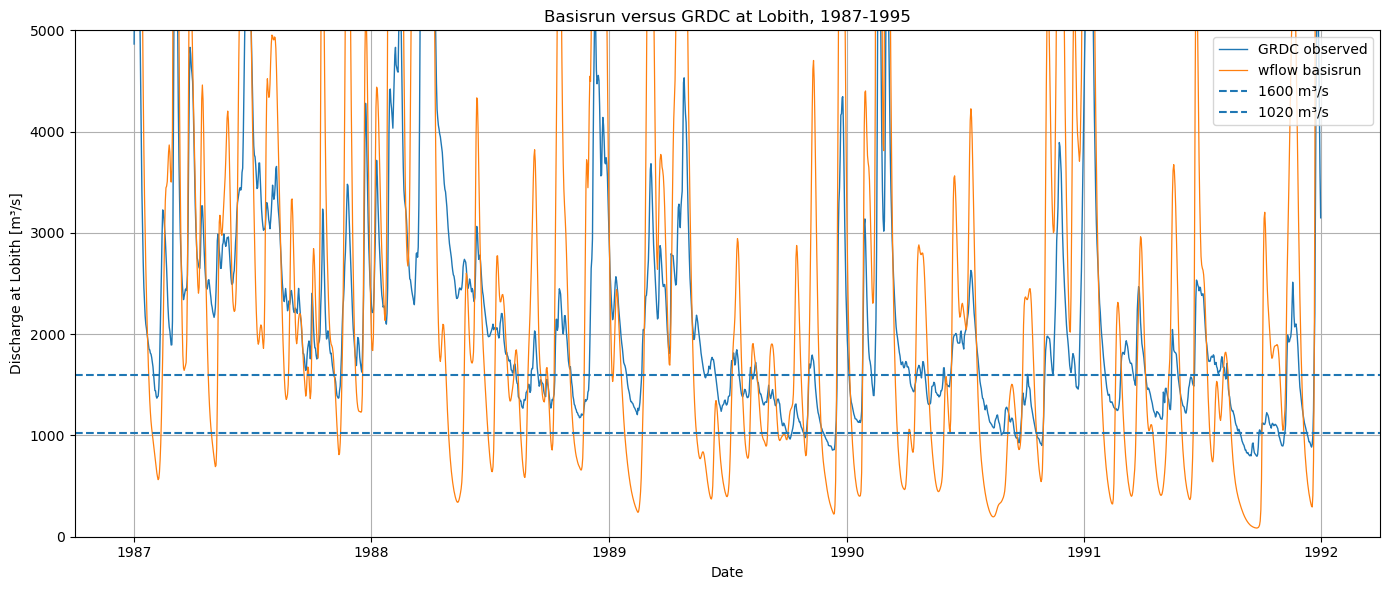

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["date"],
    comparison["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison["date"],
    comparison["Q_basis_m3s"],
    label="wflow basisrun",
    linewidth=0.9
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 5000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Basisrun versus GRDC at Lobith, 1987-1995")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
lowflow_limit = 1600

low = comparison[comparison["Q_grdc_m3s"] < lowflow_limit].copy()

print("Aantal low-flow dagen volgens GRDC:", len(low))

bias_low = (low["Q_basis_m3s"] - low["Q_grdc_m3s"]).mean()
mae_low = abs(low["Q_basis_m3s"] - low["Q_grdc_m3s"]).mean()

print("Gemiddelde fout tijdens low-flow:", round(bias_low, 1), "m3/s")
print("Gemiddelde absolute fout tijdens low-flow:", round(mae_low, 1), "m3/s")

print("Gemiddelde GRDC low-flow:", round(low["Q_grdc_m3s"].mean(), 1), "m3/s")
print("Gemiddelde model low-flow:", round(low["Q_basis_m3s"].mean(), 1), "m3/s")

print("Dagen GRDC < 1600:", (comparison["Q_grdc_m3s"] < 1600).sum())
print("Dagen model < 1600:", (comparison["Q_basis_m3s"] < 1600).sum())

print("Dagen GRDC < 1020:", (comparison["Q_grdc_m3s"] < 1020).sum())
print("Dagen model < 1020:", (comparison["Q_basis_m3s"] < 1020).sum())

Aantal low-flow dagen volgens GRDC: 669
Gemiddelde fout tijdens low-flow: -147.0 m3/s
Gemiddelde absolute fout tijdens low-flow: 595.2 m3/s
Gemiddelde GRDC low-flow: 1264.1 m3/s
Gemiddelde model low-flow: 1117.1 m3/s
Dagen GRDC < 1600: 669
Dagen model < 1600: 760
Dagen GRDC < 1020: 96
Dagen model < 1020: 485


In [30]:
print("Start comparison:", comparison["date"].min())
print("Einde comparison:", comparison["date"].max())
print("Aantal dagen:", len(comparison))

Start comparison: 1987-01-01 00:00:00
Einde comparison: 1991-12-31 00:00:00
Aantal dagen: 1826


In [31]:
factors = {
    "FirstZoneCapacity.tbl": 1.5,
    "MaxLeakage.tbl": 0.5
}

In [32]:
maxleakage_file = Path(parameter_set.directory) / "intbl" / "MaxLeakage.tbl"

print(maxleakage_file)
print(maxleakage_file.exists())
print(maxleakage_file.read_text())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/MaxLeakage.tbl
True
<,10]	<,14]	1 0.0



In [33]:
factors = {
    "FirstZoneCapacity.tbl": 1.5,
    "MaxLeakage.tbl": 0.5
}

model_lowflow_1 = run_calibration_model(
    run_name="lowflow_storage_leakage_1",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_lowflow_storage_leakage_1
Aangepast: intbl/FirstZoneCapacity.tbl factor: 1.5
Aangepast: intbl/MaxLeakage.tbl factor: 0.5
Model gestart
Start time: 504921600.0
End time: 820454400.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.5
Stap: 2555 Tijd: 1992-12-29 00:00:00 Q: 1827.6
Stap: 2920 Tijd: 1993-12-29 00:00:00 Q: 10864.1
Stap: 3285 Tijd: 1994-12-29 00:00:00 Q: 5357.5
Stap: 3650 Tijd: 1995-12-29 00:00:00 Q: 10540.7
Run klaar: lowflow_storage_leakage_1
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/lowflow_storage_leakage_1_lobith_daily.csv


In [34]:
def calculate_scores(data, obs_col, sim_col):
    # Alleen rijen gebruiken waar observatie en model allebei bestaan
    d = data[[obs_col, sim_col]].dropna().copy()
    
    obs = d[obs_col].astype(float)
    sim = d[sim_col].astype(float)
    
    # Bias: gemiddeld model - observatie
    bias = (sim - obs).mean()
    
    # RMSE
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    
    # Log NSE
    # Kleine waarde om log(0) te voorkomen
    eps = 1.0
    
    log_obs = np.log(obs.clip(lower=eps))
    log_sim = np.log(sim.clip(lower=eps))
    
    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()
    
    return {
        "bias_m3s": bias,
        "rmse_m3s": rmse,
        "log_nse": log_nse,
        "n_days": len(d)
    }

In [35]:
def make_score_table(data, model_columns, obs_col="Q_grdc_m3s"):
    rows = []
    
    for name, sim_col in model_columns.items():
        scores = calculate_scores(data, obs_col, sim_col)
        
        scores["run"] = name
        rows.append(scores)
    
    score_table = pd.DataFrame(rows)
    
    score_table = score_table[
        ["run", "bias_m3s", "rmse_m3s", "log_nse", "n_days"]
    ]
    
    score_table["bias_m3s"] = score_table["bias_m3s"].round(1)
    score_table["rmse_m3s"] = score_table["rmse_m3s"].round(1)
    score_table["log_nse"] = score_table["log_nse"].round(3)
    
    return score_table

In [36]:
model_columns = {
    "basisrun": "Q_basis_m3s"
}

score_table_all = make_score_table(
    comparison,
    model_columns
)

score_table_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826


In [37]:
lowflow_limit = 1600

comparison_low = comparison[
    comparison["Q_grdc_m3s"] < lowflow_limit
].copy()

score_table_low = make_score_table(
    comparison_low,
    model_columns
)

score_table_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669


In [39]:
# Zorg dat de datumkolom goed staat
model_lowflow_1["date"] = pd.to_datetime(model_lowflow_1["date"])

# Hernoem modelkolom als dat nog niet gedaan is
if "Q_model_m3s" in model_lowflow_1.columns:
    model_lowflow_1 = model_lowflow_1.rename(
        columns={"Q_model_m3s": "Q_lowflow_1_m3s"}
    )

# Voeg basisrun/GRDC comparison samen met lowflow-run
comparison_lowflow_1 = pd.merge(
    comparison,
    model_lowflow_1[["date", "Q_lowflow_1_m3s"]],
    on="date",
    how="inner"
)

print(comparison_lowflow_1.head())
print(comparison_lowflow_1.columns)

        date  Q_grdc_m3s   Q_basis_m3s  Q_lowflow_1_m3s
0 1987-01-01      4865.0  13869.678711     13869.678711
1 1987-01-02      5756.0  15741.568359     15741.568359
2 1987-01-03      6160.0  16061.675781     16061.675781
3 1987-01-04      6973.0  15124.300781     15124.300781
4 1987-01-05      7579.0  13978.630859     13978.630859
Index(['date', 'Q_grdc_m3s', 'Q_basis_m3s', 'Q_lowflow_1_m3s'], dtype='object')


In [40]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "lowflow_1": "Q_lowflow_1_m3s"
}

score_table_all = make_score_table(
    comparison_lowflow_1,
    model_columns
)

score_table_low = make_score_table(
    comparison_lowflow_1[
        comparison_lowflow_1["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_table_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,lowflow_1,582.0,1876.4,-1.042,1826


In [41]:
lowflow_limit = 1600

low = comparison_lowflow_1[
    comparison_lowflow_1["Q_grdc_m3s"] < lowflow_limit
].copy()

bias_low = (low["Q_lowflow_1_m3s"] - low["Q_grdc_m3s"]).mean()
mae_low = abs(low["Q_lowflow_1_m3s"] - low["Q_grdc_m3s"]).mean()

print("Aantal low-flow dagen volgens GRDC:", len(low))
print("Gemiddelde fout tijdens low-flow:", round(bias_low, 1), "m3/s")
print("Gemiddelde absolute fout tijdens low-flow:", round(mae_low, 1), "m3/s")

print("Gemiddelde GRDC low-flow:", round(low["Q_grdc_m3s"].mean(), 1))
print("Gemiddelde model low-flow:", round(low["Q_lowflow_1_m3s"].mean(), 1))

print("Dagen GRDC < 1600:", (comparison_lowflow_1["Q_grdc_m3s"] < 1600).sum())
print("Dagen model < 1600:", (comparison_lowflow_1["Q_lowflow_1_m3s"] < 1600).sum())

print("Dagen GRDC < 1020:", (comparison_lowflow_1["Q_grdc_m3s"] < 1020).sum())
print("Dagen model < 1020:", (comparison_lowflow_1["Q_lowflow_1_m3s"] < 1020).sum())

Aantal low-flow dagen volgens GRDC: 669
Gemiddelde fout tijdens low-flow: -147.0 m3/s
Gemiddelde absolute fout tijdens low-flow: 595.2 m3/s
Gemiddelde GRDC low-flow: 1264.1
Gemiddelde model low-flow: 1117.1
Dagen GRDC < 1600: 669
Dagen model < 1600: 760
Dagen GRDC < 1020: 96
Dagen model < 1020: 485


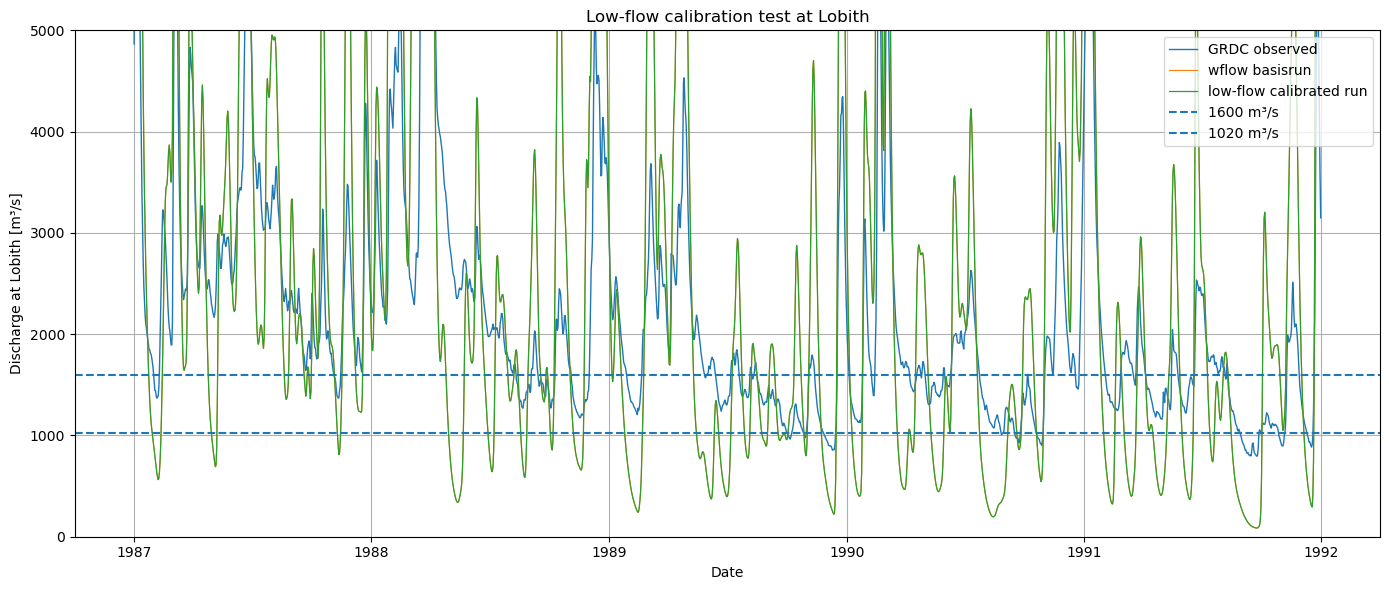

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_lowflow_1["date"],
    comparison_lowflow_1["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_lowflow_1["date"],
    comparison_lowflow_1["Q_basis_m3s"],
    label="wflow basisrun",
    linewidth=0.8
)

plt.plot(
    comparison_lowflow_1["date"],
    comparison_lowflow_1["Q_lowflow_1_m3s"],
    label="low-flow calibrated run",
    linewidth=0.9
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 5000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow calibration test at Lobith")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
verschil = comparison_lowflow_1["Q_lowflow_1_m3s"] - comparison_lowflow_1["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal verschillende waarden:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 0.0
Gemiddeld verschil: 0.0
Aantal verschillende waarden: 0


In [44]:
print(model_lowflow_1.head())
print(model_lowflow_1.columns)

print(model_basis.head())
print(model_basis.columns)

          date  Q_lowflow_1_m3s
365 1987-01-01     13869.678711
366 1987-01-02     15741.568359
367 1987-01-03     16061.675781
368 1987-01-04     15124.300781
369 1987-01-05     13978.630859
Index(['date', 'Q_lowflow_1_m3s'], dtype='object')
          date   Q_basis_m3s
365 1987-01-01  13869.678711
366 1987-01-02  15741.568359
367 1987-01-03  16061.675781
368 1987-01-04  15124.300781
369 1987-01-05  13978.630859
Index(['date', 'Q_basis_m3s'], dtype='object')


In [45]:
test_merge = pd.merge(
    model_basis,
    model_lowflow_1,
    on="date",
    how="inner",
    suffixes=("_basis", "_lowflow")
)

print(test_merge.head())
print(test_merge.columns)

        date   Q_basis_m3s  Q_lowflow_1_m3s
0 1987-01-01  13869.678711     13869.678711
1 1987-01-02  15741.568359     15741.568359
2 1987-01-03  16061.675781     16061.675781
3 1987-01-04  15124.300781     15124.300781
4 1987-01-05  13978.630859     13978.630859
Index(['date', 'Q_basis_m3s', 'Q_lowflow_1_m3s'], dtype='object')


In [46]:
run_dirs = sorted(
    temp_dir.glob("run_*lowflow*"),
    key=lambda p: p.stat().st_mtime
)

for run_dir in run_dirs:
    print(run_dir)

/home/niels/BEP-Niels/temp_runs/run_lowflow_storage_leakage_1


In [47]:
run_dir = run_dirs[-1]

print("Gekozen runmap:")
print(run_dir)

Gekozen runmap:
/home/niels/BEP-Niels/temp_runs/run_lowflow_storage_leakage_1


In [48]:
tbl_file = run_dir / "intbl" / "FirstZoneCapacity.tbl"

print(tbl_file)
print(tbl_file.exists())
print(tbl_file.read_text())

/home/niels/BEP-Niels/temp_runs/run_lowflow_storage_leakage_1/intbl/FirstZoneCapacity.tbl
True
1 1 1 600.0
2 1 1 10650.0
3 1 1 10650.0
4 1 1 10650.0
5 1 1 10650.0
6 1 1 10650.0
1 2 1 4800.0
2 2 1 15000.0
3 2 1 15000.0
4 2 1 15000.0
5 2 1 15000.0
6 2 1 15000.0
1 3 1 600.0
2 3 1 1500.0
3 3 1 1500.0
4 3 1 1500.0
5 3 1 1500.0
6 3 1 1500.0
1 4 1 1200.0
2 4 1 21300.0
3 4 1 21300.0
4 4 1 21300.0
5 4 1 21300.0
6 4 1 21300.0
1 5 1 1200.0
2 5 1 21300.0
3 5 1 21300.0
4 5 1 21300.0
5 5 1 21300.0
6 5 1 21300.0
1 6 1 1200.0
2 6 1 21300.0
3 6 1 21300.0
4 6 1 21300.0
5 6 1 21300.0
6 6 1 21300.0
1 7 1 1800.0
2 7 1 10125.0
3 7 1 10125.0
4 7 1 10125.0
5 7 1 10125.0
6 7 1 10125.0
1 8 1 600.0
2 8 1 2625.0
3 8 1 2625.0
4 8 1 2625.0
5 8 1 2625.0
6 8 1 2625.0
1 9 1 1200.0
2 9 1 21300.0
3 9 1 21300.0
4 9 1 21300.0
5 9 1 21300.0
6 9 1 21300.0
1 10 1 1200.0
2 10 1 21300.0
3 10 1 21300.0
4 10 1 21300.0
5 10 1 21300.0
6 10 1 21300.0
1 11 1 19200.0
2 11 1 36000.0
3 11 1 36000.0
4 11 1 36000.0
5 11 1 36000.0
6 11 1 

In [49]:
original_tbl = Path(parameter_set.directory) / "intbl" / "FirstZoneCapacity.tbl"

print("Origineel:")
print(original_tbl.read_text())

print("Aangepaste run:")
print(tbl_file.read_text())

Origineel:
1	1	1	400
2	1	1	7100
3	1	1	7100
4	1	1	7100
5	1	1	7100
6	1	1	7100
1	2	1	3200
2	2	1	10000
3	2	1	10000
4	2	1	10000
5	2	1	10000
6	2	1	10000
1	3	1	400
2	3	1	1000
3	3	1	1000
4	3	1	1000
5	3	1	1000
6	3	1	1000
1	4	1	800
2	4	1	14200
3	4	1	14200
4	4	1	14200
5	4	1	14200
6	4	1	14200
1	5	1	800
2	5	1	14200
3	5	1	14200
4	5	1	14200
5	5	1	14200
6	5	1	14200
1	6	1	800
2	6	1	14200
3	6	1	14200
4	6	1	14200
5	6	1	14200
6	6	1	14200
1	7	1	1200
2	7	1	6750
3	7	1	6750
4	7	1	6750
5	7	1	6750
6	7	1	6750
1	8	1	400
2	8	1	1750
3	8	1	1750
4	8	1	1750
5	8	1	1750
6	8	1	1750
1	9	1	800
2	9	1	14200
3	9	1	14200
4	9	1	14200
5	9	1	14200
6	9	1	14200
1	10	1	800
2	10	1	14200
3	10	1	14200
4	10	1	14200
5	10	1	14200
6	10	1	14200
1	11	1	12800
2	11	1	24000
3	11	1	24000
4	11	1	24000
5	11	1	24000
6	11	1	24000
1	12	1	400
2	12	1	1250
3	12	1	1250
4	12	1	1250
5	12	1	1250
6	12	1	1250
1	13	1	1600
2	13	1	3000
3	13	1	3000
4	13	1	3000
5	13	1	3000
6	13	1	3000
1	14	1	400
2	14	1	750
3	14	1	750
4	14	1	750
5	14	1	750
6	14	1	750
















In [54]:
run_dirs = sorted(temp_dir.glob("run_*lowflow*"))

for run_dir in run_dirs:
    print(run_dir)

run_dir = temp_dir / "run_lowflow_1"

print(run_dir)
print(run_dir.exists())

run_dir = sorted(
    temp_dir.glob("run_*lowflow*"),
    key=lambda p: p.stat().st_mtime
)[-1]

print("Gekozen runmap:")
print(run_dir)

/home/niels/BEP-Niels/temp_runs/run_lowflow_storage_leakage_1
/home/niels/BEP-Niels/temp_runs/run_lowflow_1
False
Gekozen runmap:
/home/niels/BEP-Niels/temp_runs/run_lowflow_storage_leakage_1


In [55]:
tbl_name = "FirstZoneCapacity.tbl"

original_tbl = Path(parameter_set.directory) / "intbl" / tbl_name
changed_tbl = run_dir / "intbl" / tbl_name

print("Origineel:")
print(original_tbl.read_text())

print("\nAangepast:")
print(changed_tbl.read_text())

Origineel:
1	1	1	400
2	1	1	7100
3	1	1	7100
4	1	1	7100
5	1	1	7100
6	1	1	7100
1	2	1	3200
2	2	1	10000
3	2	1	10000
4	2	1	10000
5	2	1	10000
6	2	1	10000
1	3	1	400
2	3	1	1000
3	3	1	1000
4	3	1	1000
5	3	1	1000
6	3	1	1000
1	4	1	800
2	4	1	14200
3	4	1	14200
4	4	1	14200
5	4	1	14200
6	4	1	14200
1	5	1	800
2	5	1	14200
3	5	1	14200
4	5	1	14200
5	5	1	14200
6	5	1	14200
1	6	1	800
2	6	1	14200
3	6	1	14200
4	6	1	14200
5	6	1	14200
6	6	1	14200
1	7	1	1200
2	7	1	6750
3	7	1	6750
4	7	1	6750
5	7	1	6750
6	7	1	6750
1	8	1	400
2	8	1	1750
3	8	1	1750
4	8	1	1750
5	8	1	1750
6	8	1	1750
1	9	1	800
2	9	1	14200
3	9	1	14200
4	9	1	14200
5	9	1	14200
6	9	1	14200
1	10	1	800
2	10	1	14200
3	10	1	14200
4	10	1	14200
5	10	1	14200
6	10	1	14200
1	11	1	12800
2	11	1	24000
3	11	1	24000
4	11	1	24000
5	11	1	24000
6	11	1	24000
1	12	1	400
2	12	1	1250
3	12	1	1250
4	12	1	1250
5	12	1	1250
6	12	1	1250
1	13	1	1600
2	13	1	3000
3	13	1	3000
4	13	1	3000
5	13	1	3000
6	13	1	3000
1	14	1	400
2	14	1	750
3	14	1	750
4	14	1	750
5	14	1	750
6	14	1	750
















In [56]:
for tbl_name in factors.keys():
    original_tbl = Path(parameter_set.directory) / "intbl" / tbl_name
    changed_tbl = run_dir / "intbl" / tbl_name

    print("\n===================")
    print(tbl_name)
    print("===================")

    print("Origineel:")
    print(original_tbl.read_text())

    print("Aangepast:")
    print(changed_tbl.read_text())


FirstZoneCapacity.tbl
Origineel:
1	1	1	400
2	1	1	7100
3	1	1	7100
4	1	1	7100
5	1	1	7100
6	1	1	7100
1	2	1	3200
2	2	1	10000
3	2	1	10000
4	2	1	10000
5	2	1	10000
6	2	1	10000
1	3	1	400
2	3	1	1000
3	3	1	1000
4	3	1	1000
5	3	1	1000
6	3	1	1000
1	4	1	800
2	4	1	14200
3	4	1	14200
4	4	1	14200
5	4	1	14200
6	4	1	14200
1	5	1	800
2	5	1	14200
3	5	1	14200
4	5	1	14200
5	5	1	14200
6	5	1	14200
1	6	1	800
2	6	1	14200
3	6	1	14200
4	6	1	14200
5	6	1	14200
6	6	1	14200
1	7	1	1200
2	7	1	6750
3	7	1	6750
4	7	1	6750
5	7	1	6750
6	7	1	6750
1	8	1	400
2	8	1	1750
3	8	1	1750
4	8	1	1750
5	8	1	1750
6	8	1	1750
1	9	1	800
2	9	1	14200
3	9	1	14200
4	9	1	14200
5	9	1	14200
6	9	1	14200
1	10	1	800
2	10	1	14200
3	10	1	14200
4	10	1	14200
5	10	1	14200
6	10	1	14200
1	11	1	12800
2	11	1	24000
3	11	1	24000
4	11	1	24000
5	11	1	24000
6	11	1	24000
1	12	1	400
2	12	1	1250
3	12	1	1250
4	12	1	1250
5	12	1	1250
6	12	1	1250
1	13	1	1600
2	13	1	3000
3	13	1	3000
4	13	1	3000
5	13	1	3000
6	13	1	3000
1	14	1	400
2	14	1	750
3	14	1	750
4	14	1	750
5	14	1	750
6	

In [53]:
print("\nControle aangepaste parameters:")

for tbl_name in factors.keys():
    tbl_file = cfg_dir_test / "intbl" / tbl_name
    
    print("\n---", tbl_name, "---")
    print("Bestaat:", tbl_file.exists())
    
    if tbl_file.exists():
        print(tbl_file.read_text())

        


Controle aangepaste parameters:


NameError: name 'cfg_dir_test' is not defined